# Unit 4 · Hidden Markov models

Course: **21CSC305P — Machine Learning**

## Aim
Use a two-state HMM to predict whether the next observed traffic hour is busy.

## Assignment tasks
1. Implement HMM to predict the sequential data.

## About this transport dataset
This is **real hourly road-sensor data** from westbound Interstate 94 between Minneapolis and Saint Paul, USA. A road sensor counts vehicles passing during each hour. We use **1,008 consecutive hours (42 days), from 13 April 2017 at 10:00 to 25 May 2017 at 09:00**, in the source's local timestamps.

**traffic_volume**: vehicles counted in that hour. **temperature_c**: air temperature in degrees Celsius. **date_time** identifies the hour and is not a numerical model feature.

The original dataset has 48,204 rows and includes weather and holidays from 2012–2018. Repeated weather descriptions can share a timestamp; their traffic counts were verified identical before keeping the first entry. The teaching CSV uses the first six weeks of the longest continuous hourly sequence. Temperature was converted from Kelvin by subtracting 273.15. No missing hours were filled and no measurements were invented.

Source: [UCI Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume). Citation: Hogue, J. (2019), DOI: 10.24432/C5X60B. License: CC BY 4.0. The complete original compressed CSV is included.

**What to tell faculty:** “I am studying traffic patterns using real vehicle counts from a highway sensor.” High vehicle count means a busy hour; without speed or capacity data it does not prove congestion. This small window is a classroom demonstration, not a validation across roads or seasons.

Run cells from top to bottom. Keep the `data` folder beside `notebooks`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/traffic.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/traffic.csv')

df['date_time'] = pd.to_datetime(df['date_time'])
print('Number of traffic hours:', len(df))

Number of traffic hours: 1008


## Understand the sequence
Keep the continuous hourly order. For this supervised teaching HMM, the hidden regime is **night-time or daytime**, labelled in training using `6 <= hour < 20`. The observation is **light or heavy traffic**, with heavy meaning at least 4000 vehicles/hour. During testing, hide regime labels and use only previously observed traffic categories. We deliberately withhold the clock to demonstrate filtering; a practical traffic model would use the available hour-of-day directly. We learn tables by counting labelled training data, not by unsupervised Baum-Welch.

In [2]:
data = df.copy()
split = int(len(data) * 0.8)
hour = data['date_time'].dt.hour
states = ((hour >= 6) & (hour < 20)).astype(int).to_numpy()
observations = (data['traffic_volume'] >= 4000).astype(int).to_numpy()
print('State 0 = night-time regime; state 1 = daytime regime')
print('Observation 0 = light traffic; observation 1 = heavy traffic')
display(data.head())

State 0 = night-time regime; state 1 = daytime regime
Observation 0 = light traffic; observation 1 = heavy traffic


,date_time,traffic_volume,temperature_c
0,2017-04-13 10:00:00,4576,8.26
1,2017-04-13 11:00:00,5033,8.75
2,2017-04-13 12:00:00,5138,9.00
3,2017-04-13 13:00:00,5296,9.19
4,2017-04-13 14:00:00,5400,10.26


## Step 1 · Learn two probability tables
`transition[i, j]` tells us how often state i is followed by state j. `emission[i, j]` tells us how often state i produces observation j. Starting counts at one prevents zero probabilities (add-one smoothing). Only the first 80% of rows contribute to these tables.

,Next night-time,Next daytime
Night-time,0.899,0.101
Daytime,0.074,0.926


,Light traffic,Heavy traffic
Night-time,0.991,0.009
Daytime,0.165,0.835


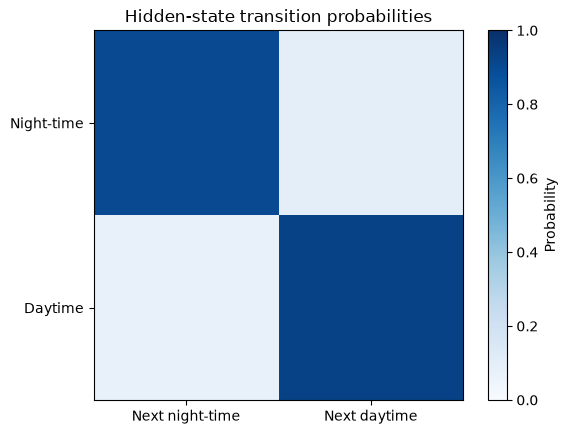

In [3]:
transition = np.ones((2, 2))
emission = np.ones((2, 2))
initial = np.ones(2)
initial[states[0]] += 1
initial = initial / initial.sum()

for i in range(split - 1):
    transition[states[i], states[i + 1]] += 1
for i in range(split):
    emission[states[i], observations[i]] += 1

transition = transition / transition.sum(axis=1, keepdims=True)
emission = emission / emission.sum(axis=1, keepdims=True)
display(pd.DataFrame(transition, index=['Night-time', 'Daytime'], columns=['Next night-time', 'Next daytime']).round(3))
display(pd.DataFrame(emission, index=['Night-time', 'Daytime'], columns=['Light traffic', 'Heavy traffic']).round(3))

plt.imshow(transition, vmin=0, vmax=1, cmap='Blues')
plt.xticks([0, 1], ['Next night-time', 'Next daytime'])
plt.yticks([0, 1], ['Night-time', 'Daytime'])
plt.colorbar(label='Probability')
plt.title('Hidden-state transition probabilities')
plt.show()

## Step 2 · Predict, then update
`belief` is our probability for each hidden state. Matrix multiplication predicts the next state, then the next observation. After making that prediction, we reveal the actual traffic category and update the belief. Dividing by the sum normalizes the forward filter and avoids extremely small accumulated probabilities.

HMM test accuracy: 0.876
Previous-hour category baseline: 0.916
Probability the following traffic hour is heavy: 0.774


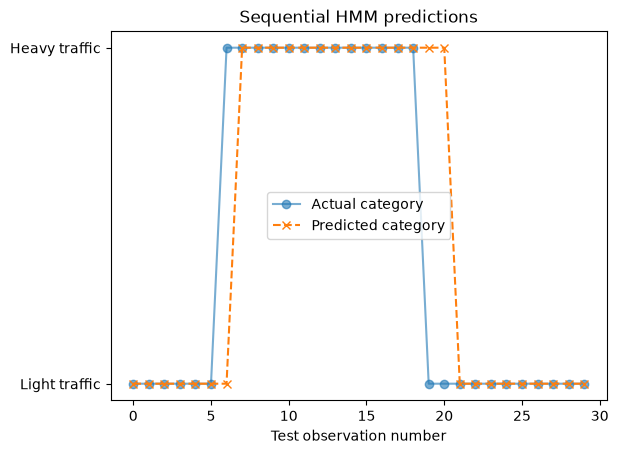

In [4]:
predictions = []
probabilities = []
belief = initial.copy()

for i, observation in enumerate(observations):
    if i == 0:
        next_state = belief
    else:
        next_state = belief @ transition
    next_observation = next_state @ emission

    # Record the test prediction BEFORE revealing this observation.
    if i >= split:
        predictions.append(int(np.argmax(next_observation)))
        probabilities.append(next_observation[1])

    belief = next_state * emission[:, observation]
    belief = belief / belief.sum()

from sklearn.metrics import accuracy_score
actual = observations[split:]
print('HMM test accuracy:', round(accuracy_score(actual, predictions), 3))
print('Previous-hour category baseline:', round(accuracy_score(actual, observations[split - 1:-1]), 3))
print('Probability the following traffic hour is heavy:', round(float((belief @ transition @ emission)[1]), 3))

plt.plot(actual[:30], 'o-', label='Actual category', alpha=0.6)
plt.plot(predictions[:30], 'x--', label='Predicted category')
plt.yticks([0, 1], ['Light traffic', 'Heavy traffic'])
plt.xlabel('Test observation number')
plt.title('Sequential HMM predictions')
plt.legend()
plt.show()

## What to explain
The hidden regime is separate from the observed traffic category: daytime does not always mean heavy traffic. We reveal time-based regime labels only for training, then infer regime beliefs from past observed categories. The HMM predicts the next traffic category before seeing it. It approximates day/night durations using transition probabilities rather than an exact clock.

**Try:** Inspect the strongest transition.

**Viva:** What are the states and observations? What is an emission? Why normalize the belief? Why must we predict before updating?